In [2]:
import torch
import torchvision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())
print("Rice Guard environment is ready!")

PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
GPU available: False
Rice Guard environment is ready!


In [1]:
import sys

print(sys.executable)

c:\Projects\16_Rice_Guard\.venv\Scripts\python.exe


In [3]:
# Load the dataset
df = pd.read_csv("C:/Projects/16_Rice_Guard/data/raw/train.csv")
df.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [11]:
from pathlib import Path

TRAIN_IMAGE_DIR = Path(
    "C:/Projects/16_Rice_Guard/data/raw/train_images"
)

df["image_path"] = df.apply(
    lambda row: TRAIN_IMAGE_DIR / row["label"] / row["image_id"],
    axis=1
)

df["image_exists"] = df["image_path"].apply(lambda path: path.exists())

print("Images listed in CSV:", len(df))
print("Images found:", df["image_exists"].sum())
print("Missing images:", (~df["image_exists"]).sum())

Images listed in CSV: 10407
Images found: 10407
Missing images: 0


In [5]:
# Inspect the dataset structure
print("Columns:")
print(df.columns.tolist())

print("\nData Types :")
print(df.dtypes)

print("\nDataset Information : ")
df.info()

Columns:
['image_id', 'label', 'variety', 'age']

Data Types :
image_id      str
label         str
variety       str
age         int64
dtype: object

Dataset Information : 
<class 'pandas.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  10407 non-null  str  
 1   label     10407 non-null  str  
 2   variety   10407 non-null  str  
 3   age       10407 non-null  int64
dtypes: int64(1), str(3)
memory usage: 325.3 KB


In [6]:
# Checking missing and duplicate values
audit_summary = pd.DataFrame({
    "missing_values" : df.isna().sum(),
    "missing_percentage" : (df.isna().mean() * 100).round(2),
    "unique_values" : df.nunique()
})

display(audit_summary)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Image IDs:", df["image_id"].duplicated().sum())

,missing_values,missing_percentage,unique_values
image_id,0,0.0,10407
label,0,0.0,10
variety,0,0.0,10
age,0,0.0,18


Duplicate rows: 0
Duplicate Image IDs: 0


In [7]:
# Examine the disease classes
class_distribution = (
    df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="image_count")
)

class_distribution["percentage"] = (
    class_distribution['image_count'] / len(df) * 100
).round(2)

display(class_distribution)

print("Number of classes:", df["label"].nunique())

,label,image_count,percentage
0,normal,1764,16.95
1,blast,1738,16.70
2,hispa,1594,15.32
3,dead_heart,1442,13.86
4,tungro,1088,10.45
5,brown_spot,965,9.27
6,downy_mildew,620,5.96
7,bacterial_leaf_blight,479,4.60
8,bacterial_leaf_streak,380,3.65
9,bacterial_panicle_blight,337,3.24


Number of classes: 10


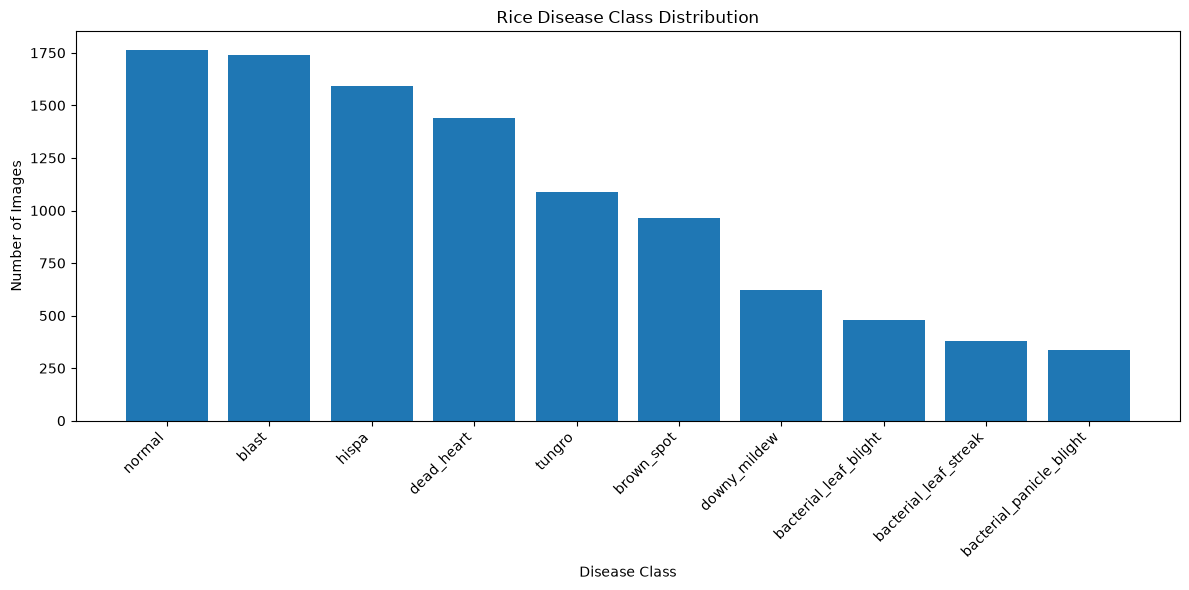

In [8]:
# Plot class Distribution
plt.figure(figsize=(12, 6))

plt.bar(
    class_distribution["label"],
    class_distribution["image_count"]
)

plt.title("Rice Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Check image dimensions and formats
from PIL import Image
import pandas as pd

image_records = []

# Inspect a sample of 500 images for speed
sample_df = df.sample(n=min(500, len(df)), random_state=42)

for image_path in sample_df["image_path"]:
    try:
        with Image.open(image_path) as image:
            image_records.append({
                "image_id": image_path.name,
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
                "format": image.format
            })
    except Exception as error:
        print(f"Could not read {image_path}: {error}")

image_info_df = pd.DataFrame(image_records)

display(image_info_df.head())

print("Image dimensions:")
display(image_info_df[["width", "height"]].describe())

print("\nImage color modes:")
print(image_info_df["mode"].value_counts())

print("\nImage formats:")
print(image_info_df["format"].value_counts())

,image_id,width,height,mode,format
0,110123.jpg,480,640,RGB,JPEG
1,103408.jpg,480,640,RGB,JPEG
2,106214.jpg,480,640,RGB,JPEG
3,100525.jpg,480,640,RGB,JPEG
4,104673.jpg,480,640,RGB,JPEG


Image dimensions:


,width,height
count,500.0,500.0
mean,480.0,640.0
std,0.0,0.0
min,480.0,640.0
25%,480.0,640.0
50%,480.0,640.0
75%,480.0,640.0
max,480.0,640.0



Image color modes:
mode
RGB    500
Name: count, dtype: int64

Image formats:
format
JPEG    500
Name: count, dtype: int64


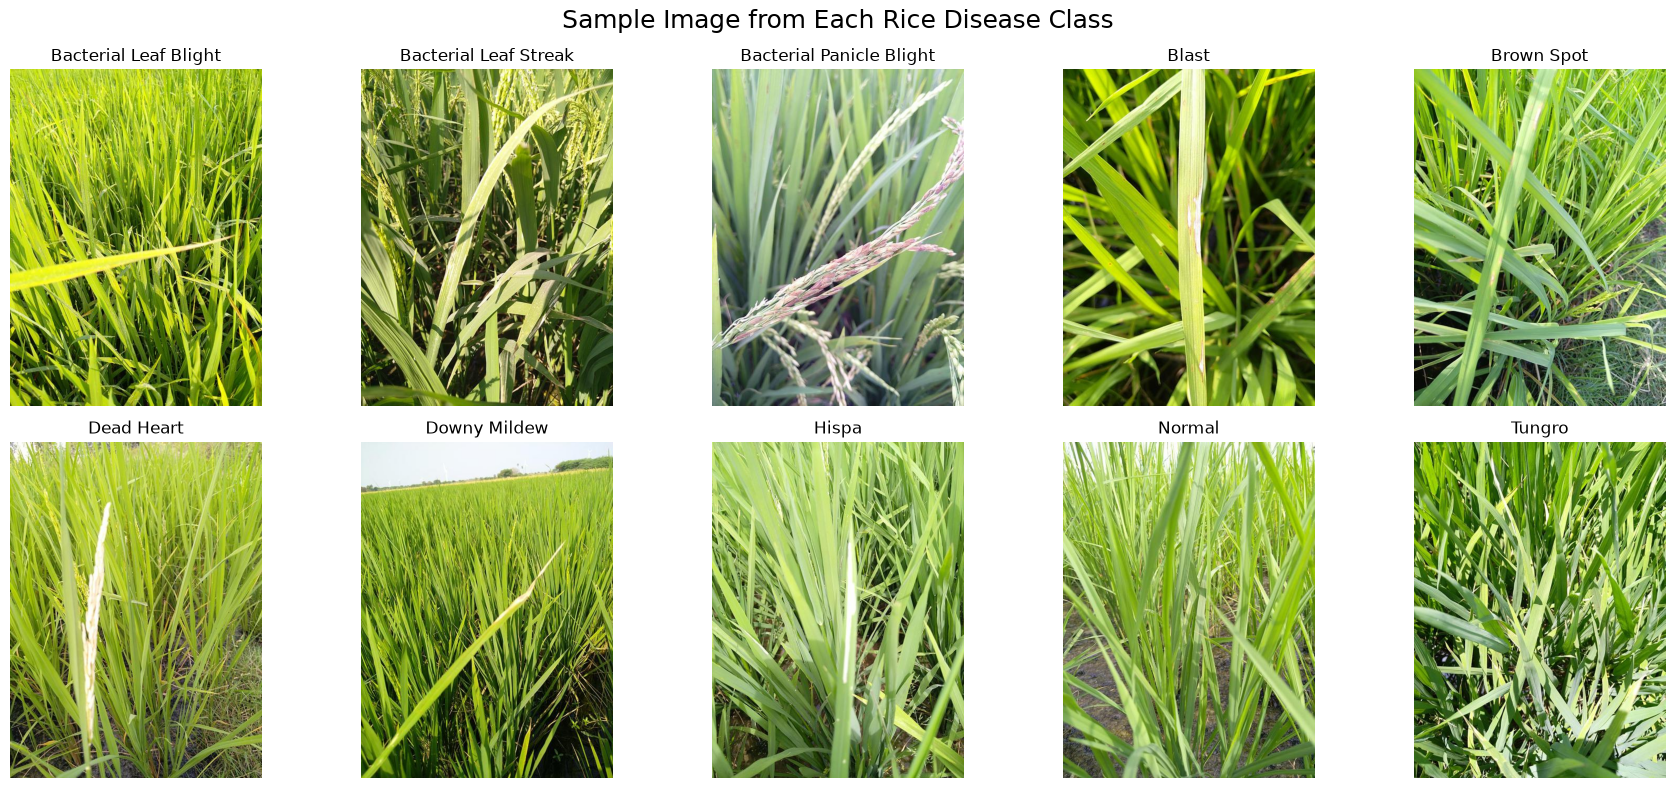

In [13]:
# Display sample images from every class
import matplotlib.pyplot as plt
from PIL import Image

labels = sorted(df["label"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 8)
)

axes = axes.flatten()

for index, label in enumerate(labels):
    sample_row = (
        df[df["label"] == label]
        .sample(n=1, random_state=42)
        .iloc[0]
    )

    with Image.open(sample_row["image_path"]) as image:
        axes[index].imshow(image.convert("RGB"))

    axes[index].set_title(label.replace("_", " ").title())
    axes[index].axis("off")

plt.suptitle(
    "Sample Image from Each Rice Disease Class",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [15]:
# Check alll images for corruption

from PIL import Image
from tqdm import tqdm
corrupted_images = []

for image_path in tqdm(df["image_path"], desc="Checking images"):
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        corrupted_images.append({
            "image_path": str(image_path),
            "error": str(error)
        })
print("Corrupted images:", len(corrupted_images))

Checking images: 100%|██████████| 10407/10407 [01:40<00:00, 103.65it/s]

Corrupted images: 0


In [16]:
# Create stratified dataset splits
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation Images:", len(validation_df))
print("Test images:", len(test_df))

Training images: 7284
Validation Images: 1561
Test images: 1562


In [17]:
# verify the class proportion
split_summary = pd.DataFrame({
    "full_dataset": df["label"].value_counts(normalize=True),
    "train": train_df["label"].value_counts(normalize=True),
    "validation": validation_df["label"].value_counts(normalize=True),
    "test": test_df["label"].value_counts(normalize=True)
}).round(4)

display(split_summary)

,full_dataset,train,validation,test
label,,,,
normal,0.1695,0.1695,0.1691,0.1697
blast,0.1670,0.1669,0.1672,0.1671
hispa,0.1532,0.1532,0.1531,0.1530
dead_heart,0.1386,0.1385,0.1384,0.1389
tungro,0.1045,0.1046,0.1044,0.1044
brown_spot,0.0927,0.0927,0.0929,0.0928
downy_mildew,0.0596,0.0596,0.0596,0.0595
bacterial_leaf_blight,0.0460,0.0460,0.0461,0.0461
bacterial_leaf_streak,0.0365,0.0365,0.0365,0.0365


In [18]:
# Save the split metadata
from pathlib import Path

PROCESSED_DIR = Path(
    "C:/Projects/16_Rice_Guard/data/processed"
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train_metadata.csv", index=False)
validation_df.to_csv(PROCESSED_DIR / "validation_metadata.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test_metadata.csv", index=False)

print("Dataset splits saved successfully.")

Dataset splits saved successfully.


## Notebook 1 Summary: Dataset Audit and Splitting

In this notebook, the Paddy Disease Classification dataset was loaded and audited before model development.

### Dataset Overview

- Total labelled images: 10,407
- Number of classes: 10
- Metadata columns: image ID, disease label, rice variety, and crop age
- All image paths were successfully verified
- Missing image files: 0
- Duplicate image IDs: 0
- Corrupted images: 0

### Image Inspection

The dataset contains real field images with variation in:

- Lighting conditions
- Background complexity
- Leaf orientation
- Image dimensions
- Disease appearance

These variations make the dataset more realistic, but they also require image resizing, normalization, and augmentation before training.

### Class Distribution

The disease classes are not perfectly balanced. Therefore, stratified splitting was used to preserve similar class proportions across the training, validation, and test sets.

### Dataset Splits

The labelled dataset was divided into:

- Training set: 70%
- Validation set: 15%
- Internal test set: 15%

The official Kaggle test images were not used for evaluation because their true labels are hidden.

### Saved Outputs

The following metadata files were saved:

- `data/processed/train_metadata.csv`
- `data/processed/validation_metadata.csv`
- `data/processed/test_metadata.csv`

### Next Step

The next notebook will focus on image preprocessing, data augmentation, PyTorch datasets, and DataLoader creation.